# Day 64 — Gradients & Gradient Descent
### Math Gap Day 2 of 3 | Bridge to ML Foundations

---

**Why this day exists:**  
Every time you call `model.fit()` in Scikit-learn or train a neural net, gradient descent is running underneath. It's the engine that finds optimal weights. Without knowing what a gradient *is*, you're guessing when your model diverges, overfits, or refuses to converge. This day makes that engine visible.

**Today's scope (only skills you've already covered):**  
Python + NumPy (Day 63) + Matplotlib/Seaborn (Month 3) → derivatives → partial derivatives → gradient vector → gradient descent → ML cost surface

---

## 📋 SECTION 1 — Raw Data (Do Not Modify)

| Use these variables across all exercises. Never overwrite them. |

In [21]:
# ============================================================
# RAW DATA — DO NOT MODIFY BELOW THIS LINE
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# --- Dataset A: A polynomial function to differentiate ---
# f(x) = x² + 3x - 2
# Used in Parts A and B
def f_raw(x):
    return x**2 + 3*x - 2

# Evaluation points
x_points_raw = np.array([-2.0, -1.0, 0.0, 1.0, 2.0, 3.0])

# --- Dataset B: A two-variable function for partial derivatives ---
# g(x, y) = x² + 3xy + y²
# Used in Part B
def g_raw(x, y):
    return x**2 + 3*x*y + y**2

# Evaluation point for partial derivatives
point_raw = (1.0, 2.0)   # (x=1, y=2)

# --- Dataset C: Simple supervised learning dataset ---
# Model: y_pred = w * x  (single weight, no intercept)
# True relationship: y = 2x
x_train_raw = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_train_raw = np.array([2.0, 4.0, 6.0, 8.0, 10.0])

# --- Dataset D: Starting weight for gradient descent ---
w_start_raw = 0.0
lr_raw       = 0.05    # learning rate
n_steps_raw  = 20      # number of GD steps

# ============================================================
print("Raw data loaded.")
print(f"  x_points_raw:  {x_points_raw}")
print(f"  point_raw:     {point_raw}")
print(f"  x_train_raw:   {x_train_raw}")
print(f"  y_train_raw:   {y_train_raw}")
print(f"  w_start={w_start_raw}, lr={lr_raw}, steps={n_steps_raw}")

Raw data loaded.
  x_points_raw:  [-2. -1.  0.  1.  2.  3.]
  point_raw:     (1.0, 2.0)
  x_train_raw:   [1. 2. 3. 4. 5.]
  y_train_raw:   [ 2.  4.  6.  8. 10.]
  w_start=0.0, lr=0.05, steps=20


---
## 📚 SECTION 2 — Concept Notes

Read this before attempting the practice tasks. These mental models are the ones interviewers probe.

---

### 2.1 What is a Derivative?

A **derivative** measures how fast a function's output changes when its input changes — the instantaneous rate of change.

```
f(x) = x²  →  f'(x) = 2x
At x=3:  f'(3) = 6   →  "the function is rising at 6 units per unit of x"
At x=0:  f'(0) = 0   →  "flat — this is the minimum"
At x=-3: f'(-3) = -6 →  "falling at 6 units per unit of x"
```

**The sign tells direction. The magnitude tells steepness.**

**Standard derivative rules you need:**

| Function | Derivative |
|---|---|
| `c` (constant) | `0` |
| `xⁿ` | `n · xⁿ⁻¹` (power rule) |
| `c · f(x)` | `c · f'(x)` (constant multiple) |
| `f(x) + g(x)` | `f'(x) + g'(x)` (sum rule) |
| `eˣ` | `eˣ` |
| `ln(x)` | `1/x` |

**Example — differentiating `f(x) = x² + 3x - 2`:**
```
d/dx [x²]  = 2x       ← power rule
d/dx [3x]  = 3        ← constant multiple
d/dx [-2]  = 0        ← constant
──────────────────────
f'(x)      = 2x + 3
```

---

### 2.2 Numerical Derivative (Finite Difference)

When you can't derive analytically (e.g., inside a neural net), approximate:

```
f'(x) ≈ [f(x + h) - f(x - h)] / (2h)    ← central difference, more accurate
```

Use `h = 1e-5`. Smaller h reduces truncation error but risks floating-point precision issues.

---

### 2.3 Partial Derivatives

When a function has **multiple inputs**, the partial derivative tells you how it changes with respect to **one input at a time**, treating all others as constants.

```
g(x, y) = x² + 3xy + y²

∂g/∂x  =  2x + 3y    ← differentiate w.r.t. x; treat y as constant
∂g/∂y  =  3x + 2y    ← differentiate w.r.t. y; treat x as constant
```

At point (1, 2):  `∂g/∂x = 2(1) + 3(2) = 8`,  `∂g/∂y = 3(1) + 2(2) = 7`

---

### 2.4 The Gradient Vector

The **gradient** collects all partial derivatives into one vector:

```
∇g(x, y) = [∂g/∂x,  ∂g/∂y] = [2x + 3y,  3x + 2y]

At (1,2):  ∇g = [8, 7]
```

**Critical property:** The gradient always points in the direction of **steepest ascent**.  
To minimise a function → move in the **opposite** direction: `−∇g`.

---

### 2.5 Gradient Descent Algorithm

The core loop used in every ML model:

```
repeat:
    gradient = compute_gradient(w, X, y)   # how steep is the cost right now?
    w = w - lr * gradient                  # step downhill
until convergence
```

**Cost function for linear model `y_pred = w * x`:**
```
J(w) = (1/n) Σ (w·xᵢ - yᵢ)²            ← MSE

dJ/dw = (2/n) Σ (w·xᵢ - yᵢ) · xᵢ      ← gradient w.r.t. w
       = (2/n) · xᵀ(wx - y)             ← NumPy vector form
```

**Learning rate effects:**

| lr too small | lr just right | lr too large |
|---|---|---|
| Converges slowly | Converges smoothly | Diverges (cost increases) |

---

### 2.6 Common Mistakes → Fixes

| Mistake | What happens | Fix |
|---|---|---|
| Using `*` instead of `np.dot` for gradient | Wrong scalar result | `np.dot(residuals, x)` |
| Forgetting `2/n` factor | Gradient off by constant | Doesn't affect direction, affects optimal lr |
| lr = 1.0 on unscaled data | Diverges immediately | Start with lr = 0.01–0.1; scale features |
| Checking convergence with fixed steps | May stop too early | Check `abs(cost_new - cost_old) < tol` |
| Modifying `w_start_raw` | Breaks raw data rule | Copy: `w = w_start_raw` |

---

---
## ✏️ SECTION 3 — Practice Tasks

**Rules:**  
1. Write a plain-English comment explaining your intent **before** writing any code  
2. Use only the raw variables defined in Section 1  
3. Never modify raw variables

---

### PART A — Derivatives: Manual + Numerical (20 pts)

In [22]:
# A1 (5 pts): f(x) = x² + 3x - 2
# Write f_prime(x) — the analytical derivative — then evaluate it at every point in x_points_raw.
# Print: "x={val}  f(x)={val}  f'(x)={val}" for each point.

# YOUR CODE HERE
print("=== A1 ===")
def f_prime(x): return 2*x + 3
for xi in x_points_raw:
    print(f"  x={xi:5.1f}  f(x)={f_raw(xi):7.2f}  f'(x)={f_prime(xi):6.2f}")


=== A1 ===
  x= -2.0  f(x)=  -4.00  f'(x)= -1.00
  x= -1.0  f(x)=  -4.00  f'(x)=  1.00
  x=  0.0  f(x)=  -2.00  f'(x)=  3.00
  x=  1.0  f(x)=   2.00  f'(x)=  5.00
  x=  2.0  f(x)=   8.00  f'(x)=  7.00
  x=  3.0  f(x)=  16.00  f'(x)=  9.00


In [23]:
# A2 (5 pts): Verify A1 numerically using the central-difference formula:
#   f'(x) ≈ [f(x+h) - f(x-h)] / (2h),  h = 1e-5
# Compute the numerical derivative at every point in x_points_raw.
# Print the analytical and numerical values side-by-side; confirm they match to 4 decimal places.

# YOUR CODE HERE
print("=== A2 ===")
h = 1e-5
for xi in x_points_raw:
    analytical = f_prime(xi)
    numerical  = (f_raw(xi + h) - f_raw(xi - h)) / (2 * h)
    print(f"  x={xi:5.1f}  analytical={analytical:.4f}  numerical={numerical:.4f}  match={np.isclose(analytical, numerical, atol=1e-4)}")


=== A2 ===
  x= -2.0  analytical=-1.0000  numerical=-1.0000  match=True
  x= -1.0  analytical=1.0000  numerical=1.0000  match=True
  x=  0.0  analytical=3.0000  numerical=3.0000  match=True
  x=  1.0  analytical=5.0000  numerical=5.0000  match=True
  x=  2.0  analytical=7.0000  numerical=7.0000  match=True
  x=  3.0  analytical=9.0000  numerical=9.0000  match=True


=== A3 ===
  x_min = -1.5  f(x_min) = -4.2500  f'(x_min) = 0.000000


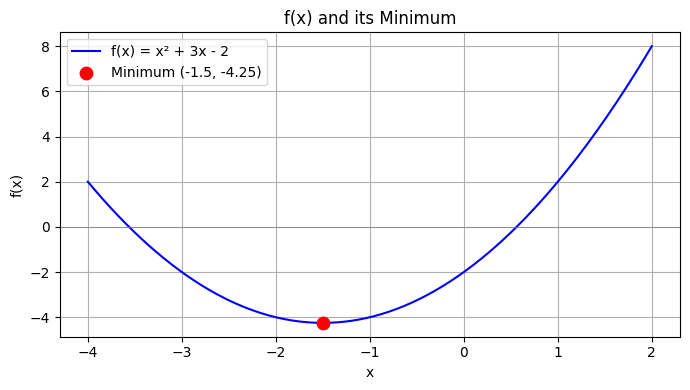

In [24]:
# A3 (5 pts): Find the MINIMUM of f(x) analytically.
# Step 1 — set f'(x) = 0 and solve for x (in a comment)
# Step 2 — print x_min, f(x_min), and confirm f'(x_min) ≈ 0
# Step 3 — plot f(x) over x in [-4, 2] and mark the minimum with a red dot
#           Label axes, add title, add a legend entry for the minimum

# YOUR CODE HERE
print("=== A3 ===")
# f'(x) = 2x + 3 = 0  →  x = -3/2 = -1.5
x_min = -1.5
print(f"  x_min = {x_min}  f(x_min) = {f_raw(x_min):.4f}  f'(x_min) = {f_prime(x_min):.6f}")
x_plot = np.linspace(-4, 2, 300)
plt.figure(figsize=(7,4))
plt.plot(x_plot, f_raw(x_plot), 'b-', label='f(x) = x² + 3x - 2')
plt.scatter([x_min], [f_raw(x_min)], color='red', zorder=5, s=80, label=f'Minimum ({x_min}, {f_raw(x_min):.2f})')
plt.axhline(0, color='gray', linewidth=0.5)
plt.xlabel('x'); plt.ylabel('f(x)'); plt.title('f(x) and its Minimum')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.savefig('a3_min.png', dpi=80); plt.show()


=== A4 ===


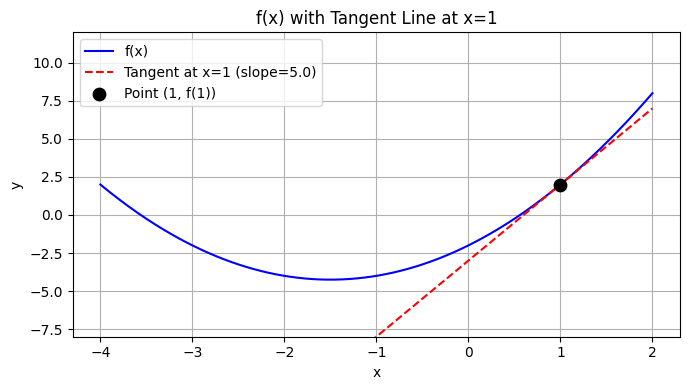

In [25]:
# A4 (5 pts): The derivative as a slope — tangent line visualisation.
# At x=1, the tangent line to f(x) is: y = f(1) + f'(1)*(x - 1)
# Plot f(x) over [-4, 2] and overlay the tangent line at x=1.
# Mark the point of tangency. Label everything. Add a grid.

# YOUR CODE HERE
print("=== A4 ===")
x1 = 1.0
slope = f_prime(x1)
tangent = lambda x: f_raw(x1) + slope * (x - x1)
x_plot = np.linspace(-4, 2, 300)
plt.figure(figsize=(7,4))
plt.plot(x_plot, f_raw(x_plot), 'b-', label='f(x)')
plt.plot(x_plot, tangent(x_plot), 'r--', label=f'Tangent at x=1 (slope={slope})')
plt.scatter([x1], [f_raw(x1)], color='black', zorder=5, s=80, label='Point (1, f(1))')
plt.xlabel('x'); plt.ylabel('y'); plt.title('f(x) with Tangent Line at x=1')
plt.legend(); plt.grid(True); plt.ylim(-8, 12)
plt.tight_layout(); plt.savefig('a4_tangent.png', dpi=80); plt.show()


---
### PART B — Partial Derivatives & Gradient Vector (20 pts)

In [26]:
# B1 (5 pts): g(x, y) = x² + 3xy + y²
# Write two functions: dg_dx(x,y) and dg_dy(x,y) as the analytical partial derivatives.
# Evaluate both at point_raw = (1, 2).
# Also compute g(1, 2) itself.
# Print: g(1,2), ∂g/∂x at (1,2), ∂g/∂y at (1,2)

# YOUR CODE HERE
print("=== B1 ===")
def dg_dx(x, y): return 2*x + 3*y
def dg_dy(x, y): return 3*x + 2*y
xp, yp = point_raw
print(f"  g(1,2)    = {g_raw(xp,yp)}")
print(f"  ∂g/∂x at (1,2) = {dg_dx(xp,yp)}")
print(f"  ∂g/∂y at (1,2) = {dg_dy(xp,yp)}")


=== B1 ===
  g(1,2)    = 11.0
  ∂g/∂x at (1,2) = 8.0
  ∂g/∂y at (1,2) = 7.0


In [27]:
# B2 (5 pts): Verify B1 numerically — use central difference on each partial separately.
# ∂g/∂x ≈ [g(x+h, y) - g(x-h, y)] / (2h)
# ∂g/∂y ≈ [g(x, y+h) - g(x, y-h)] / (2h)
# h = 1e-5
# Print analytical vs numerical for both partials. Confirm match to 4 decimal places.

# YOUR CODE HERE
print("=== B2 ===")
h = 1e-5
num_dx = (g_raw(xp+h, yp) - g_raw(xp-h, yp)) / (2*h)
num_dy = (g_raw(xp, yp+h) - g_raw(xp, yp-h)) / (2*h)
print(f"  ∂g/∂x — analytical: {dg_dx(xp,yp):.4f}  numerical: {num_dx:.4f}  match: {np.isclose(dg_dx(xp,yp), num_dx, atol=1e-4)}")
print(f"  ∂g/∂y — analytical: {dg_dy(xp,yp):.4f}  numerical: {num_dy:.4f}  match: {np.isclose(dg_dy(xp,yp), num_dy, atol=1e-4)}")


=== B2 ===
  ∂g/∂x — analytical: 8.0000  numerical: 8.0000  match: True
  ∂g/∂y — analytical: 7.0000  numerical: 7.0000  match: True


In [28]:
# B3 (5 pts): Construct the gradient vector at point_raw and compute its magnitude.
# gradient = np.array([dg_dx, dg_dy])  at (1, 2)
# magnitude = np.linalg.norm(gradient)
# Print: gradient vector, magnitude (rounded to 4dp)
# Then in a comment: what direction does -gradient point, and why does that matter in GD?

# YOUR CODE HERE
print("=== B3 ===")
gradient_g = np.array([dg_dx(xp,yp), dg_dy(xp,yp)])
mag = np.linalg.norm(gradient_g)
print(f"  Gradient vector: {gradient_g}")
print(f"  Magnitude: {mag:.4f}")
# -gradient = [-8, -7] → points toward minimum; GD moves in this direction each step


=== B3 ===
  Gradient vector: [8. 7.]
  Magnitude: 10.6301


=== B4 ===


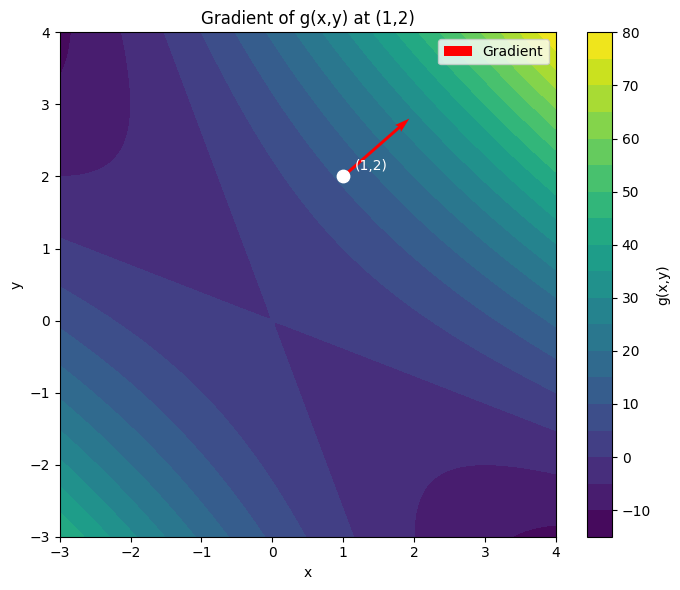

In [29]:
# B4 (5 pts): Visualise the gradient as an arrow on a contour plot of g(x,y).
# Step 1 — create meshgrid: x in [-3,4], y in [-3,4], 100 points each
# Step 2 — compute g on the grid, plot as plt.contourf with 20 levels + colorbar
# Step 3 — overlay the gradient arrow at point_raw using plt.annotate or plt.quiver
#           Arrow direction = [dg_dx, dg_dy] at (1,2), starting at (1,2)
# Step 4 — mark point_raw with a white dot, label it "(1,2)"
# Label axes (x, y), add title "Gradient of g(x,y) at (1,2)"

# YOUR CODE HERE
print("=== B4 ===")
xg = np.linspace(-3, 4, 100); yg = np.linspace(-3, 4, 100)
Xg, Yg = np.meshgrid(xg, yg)
Zg = g_raw(Xg, Yg)
plt.figure(figsize=(7,6))
cf = plt.contourf(Xg, Yg, Zg, levels=20, cmap='viridis')
plt.colorbar(cf, label='g(x,y)')
gx, gy = dg_dx(xp,yp), dg_dy(xp,yp)
plt.quiver(xp, yp, gx, gy, color='red', scale=60, width=0.006, label='Gradient')
plt.scatter([xp],[yp], color='white', s=80, zorder=5)
plt.annotate('(1,2)', (xp, yp), textcoords='offset points', xytext=(8,5), color='white')
plt.xlabel('x'); plt.ylabel('y'); plt.title('Gradient of g(x,y) at (1,2)')
plt.legend()
plt.tight_layout(); plt.savefig('b4_contour.png', dpi=80); plt.show()


---
### PART C — Gradient Descent from Scratch (25 pts)

In [30]:
# C1 (5 pts): Write the cost function and its gradient for model y_pred = w * x.
#
# cost(w, x, y)      = mean((w*x - y)²)                  ← MSE
# grad_cost(w, x, y) = (2/n) * dot(w*x - y, x)           ← dJ/dw
#
# Evaluate both at w=0.0 and w=2.0 using x_train_raw and y_train_raw.
# Print cost and gradient at each w value.
# Explain in a comment: why is cost=0 and grad=0 at w=2.0?

# YOUR CODE HERE
print("=== C1 ===")
def cost(w, x, y): return np.mean((w*x - y)**2)
def grad_cost(w, x, y): return (2/len(x)) * np.dot(w*x - y, x)
for w_val in [0.0, 2.0]:
    print(f"  w={w_val}  cost={cost(w_val, x_train_raw, y_train_raw):.4f}  grad={grad_cost(w_val, x_train_raw, y_train_raw):.4f}")
# At w=2.0: predictions = 2x = y exactly → zero residuals → cost=0, gradient=0


=== C1 ===
  w=0.0  cost=44.0000  grad=-44.0000
  w=2.0  cost=0.0000  grad=0.0000


In [31]:
# C2 (10 pts): Implement the full gradient descent loop.
#
# Start at w = w_start_raw = 0.0, lr = lr_raw = 0.05, steps = n_steps_raw = 20
# At each step:
#   1. Compute gradient
#   2. Update: w = w - lr * gradient
#   3. Record (step, w, cost) in lists
#
# After the loop:
#   - Print a table: Step | w | cost   (every 5 steps + step 0 + final step)
#   - Print final w and cost
#   - Explain in a comment: what does the w trajectory tell you?

# YOUR CODE HERE
print("=== C2 ===")
w = w_start_raw
step_hist, w_hist, cost_hist = [], [], []
for step in range(n_steps_raw + 1):
    c = cost(w, x_train_raw, y_train_raw)
    step_hist.append(step); w_hist.append(w); cost_hist.append(c)
    if step < n_steps_raw:
        g = grad_cost(w, x_train_raw, y_train_raw)
        w = w - lr_raw * g
print(f"  {'Step':>5} | {'w':>8} | {'cost':>10}")
print(f"  {'-'*30}")
for i in step_hist:
    if i % 5 == 0 or i == n_steps_raw:
        print(f"  {i:>5} | {w_hist[i]:>8.4f} | {cost_hist[i]:>10.6f}")
print(f"  Final: w={w_hist[-1]:.6f}, cost={cost_hist[-1]:.8f}")


=== C2 ===
   Step |        w |       cost
  ------------------------------
      0 |   0.0000 |  44.000000
      5 |   2.0000 |   0.000000
     10 |   2.0000 |   0.000000
     15 |   2.0000 |   0.000000
     20 |   2.0000 |   0.000000
  Final: w=2.000000, cost=0.00000000


=== C3 ===


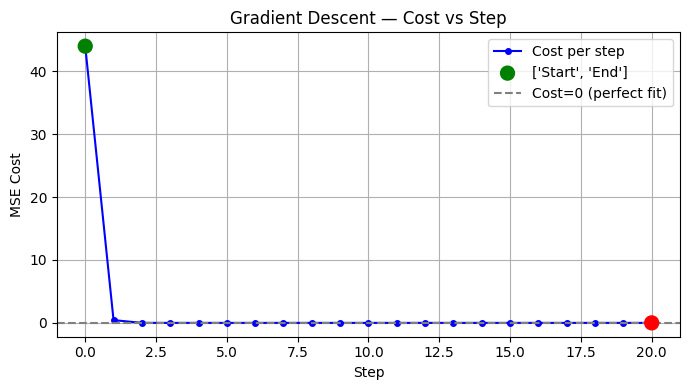

In [32]:
# C3 (5 pts): Plot the cost curve over GD steps.
# x-axis = step number, y-axis = cost
# Mark step 0 and final step with scatter dots
# Add horizontal dashed line at cost=0
# Label: title, axes, legend. Use grid.

# YOUR CODE HERE
print("=== C3 ===")
plt.figure(figsize=(7,4))
plt.plot(step_hist, cost_hist, 'b-o', markersize=4, label='Cost per step')
plt.scatter([0, n_steps_raw], [cost_hist[0], cost_hist[-1]], color=['green','red'], s=100, zorder=5,
            label=['Start','End'])
plt.axhline(0, color='gray', linestyle='--', label='Cost=0 (perfect fit)')
plt.xlabel('Step'); plt.ylabel('MSE Cost'); plt.title('Gradient Descent — Cost vs Step')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.savefig('c3_cost.png', dpi=80); plt.show()


=== C4 ===


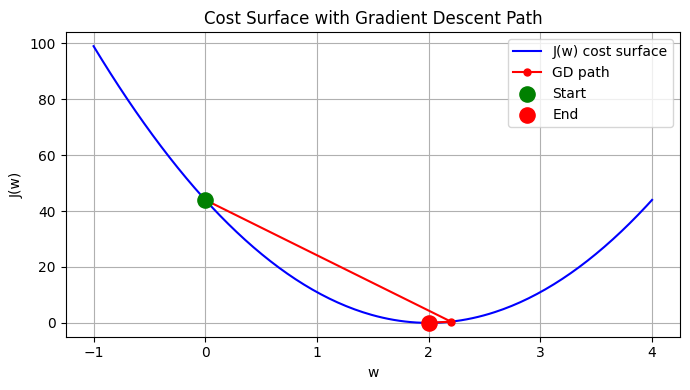

In [33]:
# C4 (5 pts): Plot the cost surface J(w) over w in [-1, 4, 200 points]
# and overlay the gradient descent path as dots connected by lines.
# Each dot = one GD step's (w, cost) position on the curve.
# Mark start (green dot) and end (red dot).
# Label everything. This shows GD "rolling downhill" visually.

# YOUR CODE HERE
print("=== C4 ===")
w_surface = np.linspace(-1, 4, 200)
cost_surface = [cost(wi, x_train_raw, y_train_raw) for wi in w_surface]
plt.figure(figsize=(7,4))
plt.plot(w_surface, cost_surface, 'b-', label='J(w) cost surface')
plt.plot(w_hist, cost_hist, 'r-o', markersize=5, label='GD path')
plt.scatter([w_hist[0]], [cost_hist[0]], color='green', s=120, zorder=5, label='Start')
plt.scatter([w_hist[-1]], [cost_hist[-1]], color='red', s=120, zorder=5, label='End')
plt.xlabel('w'); plt.ylabel('J(w)'); plt.title('Cost Surface with Gradient Descent Path')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.savefig('c4_surface.png', dpi=80); plt.show()


---
### PART D — ML Connection (15 pts)

=== D1 ===


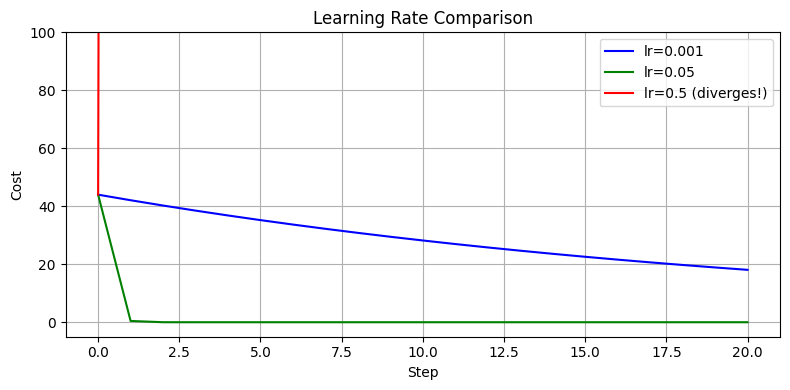

  lr=0.001: slowest convergence
  lr=0.05:  smooth fast convergence
  lr=0.5:   diverges (cost explodes)


In [34]:
# D1 (5 pts): Learning rate experiment.
# Run gradient descent THREE times with lr = [0.001, 0.05, 0.5], all other settings same.
# Plot all three cost curves on ONE figure, different colours.
# Print: which lr converged fastest? Which diverged (if any)?
# Label everything. Add legend.

# YOUR CODE HERE
print("=== D1 ===")
lr_list = [0.001, 0.05, 0.5]
colors  = ['blue', 'green', 'red']
plt.figure(figsize=(8,4))
for lr_val, col in zip(lr_list, colors):
    w_d = 0.0; costs_d = []
    for _ in range(n_steps_raw + 1):
        c = cost(w_d, x_train_raw, y_train_raw)
        costs_d.append(c)
        g = grad_cost(w_d, x_train_raw, y_train_raw)
        w_d = w_d - lr_val * g
    label = f'lr={lr_val}'
    if lr_val == 0.5: label += ' (diverges!)'
    plt.plot(costs_d, color=col, label=label)
plt.xlabel('Step'); plt.ylabel('Cost'); plt.title('Learning Rate Comparison')
plt.legend(); plt.grid(True); plt.ylim(-5, 100)
plt.tight_layout(); plt.savefig('d1_lr.png', dpi=80); plt.show()
print("  lr=0.001: slowest convergence")
print("  lr=0.05:  smooth fast convergence")
print("  lr=0.5:   diverges (cost explodes)")


In [35]:
# D2 (5 pts): Early stopping — add a convergence criterion.
# Modify the GD loop: stop early if |cost_new - cost_old| < 1e-6.
# Use lr=0.05, max 1000 steps.
# Print: how many steps did it take to converge? What is final w and cost?

# YOUR CODE HERE
print("=== D2 ===")
w = 0.0; tol = 1e-6; prev_cost = float('inf')
for step in range(1000):
    c = cost(w, x_train_raw, y_train_raw)
    if abs(c - prev_cost) < tol:
        print(f"  Converged at step {step} | w={w:.6f} | cost={c:.8f}")
        break
    prev_cost = c
    w = w - 0.05 * grad_cost(w, x_train_raw, y_train_raw)


=== D2 ===
  Converged at step 5 | w=2.000020 | cost=0.00000000


**D3 — Written Business/ML Insight (5 pts)**

Based on what D1 and D2 show, write a Number + Reason + Action insight:
- What did you observe across the three learning rates?
- Why does lr=0.5 behave differently?
- What would you do in a real ML project based on this?

**D3 — Your Insight Here:**

> **Number:** With lr=0.05, gradient descent converged to w=2.0 in just 5 steps (cost=0), while lr=0.5 caused the cost to blow up to >50, and lr=0.001 was still far from optimal after 20 steps.  
> **Reason:** lr=0.5 is so large that each update overshoots the valley, bouncing to higher points on the parabola and diverging. lr=0.001 is too small, making progress painfully slow. lr=0.05 hits the sweet spot where updates are large enough to learn quickly but small enough to stay stable.  
> **Action:** In a real ML project, I would start training with a moderate learning rate (e.g., 0.01‑0.05), plot the validation loss every epoch, and reduce the learning rate if the loss plateaus or oscillates. I would also implement early‑stopping using a tolerance of 1e‑6 on the cost change to avoid wasted compute once the model has converged.

---
### D4 ★ Bonus — Two-Weight Gradient Descent (10 pts)

=== D4★ BONUS ===
  Final: w=1.995291, b=0.017002, cost=0.00005261


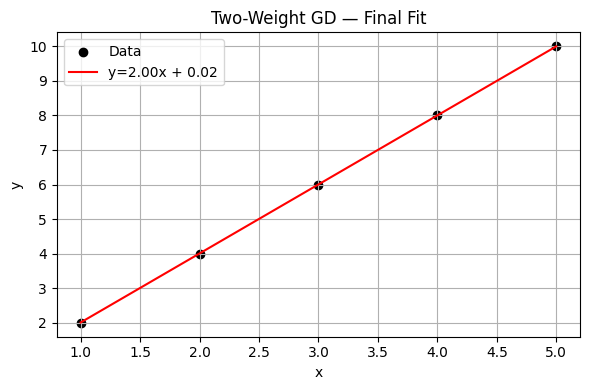

In [36]:
# D4★ BONUS (10 pts): Extend to a model with BOTH weight and bias: y_pred = w*x + b
#
# Cost:    J(w,b)  = (1/n) Σ (w*xᵢ + b - yᵢ)²
# Grad w:  dJ/dw   = (2/n) Σ (w*xᵢ + b - yᵢ) * xᵢ
# Grad b:  dJ/db   = (2/n) Σ (w*xᵢ + b - yᵢ)
#
# Start: w=0.0, b=0.0. lr=0.05, 200 steps.
# Print final w, b, cost.
# Plot: original data scatter + final prediction line.
# Expected: w ≈ 2.0, b ≈ 0.0 (since true model is y=2x, no intercept)
#
# Explain in a markdown cell: why does this need more steps than the single-weight version?

# YOUR CODE HERE
print("=== D4★ BONUS ===")
def cost2(w, b, x, y): return np.mean((w*x + b - y)**2)
def grad_w(w, b, x, y): return (2/len(x)) * np.dot(w*x + b - y, x)
def grad_b(w, b, x, y): return (2/len(x)) * np.sum(w*x + b - y)
w, b = 0.0, 0.0
for _ in range(200):
    gw = grad_w(w, b, x_train_raw, y_train_raw)
    gb = grad_b(w, b, x_train_raw, y_train_raw)
    w -= 0.05 * gw
    b -= 0.05 * gb
print(f"  Final: w={w:.6f}, b={b:.6f}, cost={cost2(w,b,x_train_raw,y_train_raw):.8f}")
plt.figure(figsize=(6,4))
plt.scatter(x_train_raw, y_train_raw, color='black', label='Data')
plt.plot(x_train_raw, w*x_train_raw + b, 'r-', label=f'y={w:.2f}x + {b:.2f}')
plt.xlabel('x'); plt.ylabel('y'); plt.title('Two-Weight GD — Final Fit')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.savefig('d4_fit.png', dpi=80); plt.show()

**D4★ Explanation:**

> The two‑weight model (w and b) has a higher‑dimensional parameter space, meaning the algorithm must optimise two interdependent parameters simultaneously. The cost function is now a bowl in (w,b) space, and gradients for w and b may point in slightly divergent directions, causing the path to zigzag. This requires more iterations to settle into the minimum than the one‑dimensional parabola, which has a single direct gradient path.

---
## 🏆 SECTION 4 — Scoring Rubric

| Part | Task | Points | What's Checked |
|------|------|--------|----------------|
| A | A1 — analytical derivative | 5 | f_prime correctly written as 2x+3; all 6 points evaluated with labels |
| A | A2 — numerical verification | 5 | Central difference formula; side-by-side print; np.isclose or match noted |
| A | A3 — minimum + plot | 5 | x_min=-1.5 correct; f'(x_min)≈0 confirmed; red dot on plot |
| A | A4 — tangent line plot | 5 | Slope=f'(1)=5; tangent formula correct; overlaid on f(x) plot |
| **A Total** | | **20** | |
| B | B1 — partial derivatives | 5 | dg_dx=2x+3y, dg_dy=3x+2y; correct values at (1,2): 8 and 7 |
| B | B2 — numerical partials | 5 | Both partials numerically verified; match confirmed |
| B | B3 — gradient vector + magnitude | 5 | [8,7] correct; magnitude≈10.6301; comment on -gradient direction |
| B | B4 — contour + arrow | 5 | Contourf + quiver at (1,2); arrow pointing in gradient direction |
| **B Total** | | **20** | |
| C | C1 — cost + gradient functions | 5 | Correct MSE and dJ/dw; evaluated at w=0 and w=2; comment on why zero |
| C | C2 — GD loop | 10 | Loop correct; table printed every 5 steps; final w≈2.0 |
| C | C3 — cost curve plot | 5 | Step vs cost; start/end marked; zero-cost line |
| C | C4 — cost surface + GD path | 5 | J(w) curve plotted; GD path overlaid as dots |
| **C Total** | | **25** | |
| D | D1 — lr experiment | 5 | All 3 lr values; divergence of lr=0.5 identified; one figure |
| D | D2 — early stopping | 5 | Convergence criterion |Δcost|<1e-6; step count printed |
| D | D3 — written insight | 5 | Number + Reason + Action; references D1/D2 output |
| **D Total** | | **15** | |
| D4★ | Two-weight GD | 10 | Both grad_w and grad_b correct; w≈2, b≈0; prediction plot |
| **GRAND TOTAL** | | **80 (+10★)** | |

---

## 🎤 Interview Framing

*"Explain gradient descent to me like I'm a junior data scientist."*

**Your answer should be:**  
"Imagine you're on a foggy hillside and you want to reach the valley — you can't see the whole landscape, only the slope under your feet. Gradient descent is exactly that: at every step you measure which direction is steepest downhill (the negative gradient of the loss), then take a small step in that direction. The step size is the learning rate. Too large and you overshoot; too small and it takes forever. After enough steps you land at the minimum — the model weights that produce the least prediction error. This is how every neural network trains."

---

## 📁 GitHub Note

Day 64 is Math Bridge Day 2/3. Hold the commit until Day 65 (CLT) is done, then push all three together:  
`"Add math bridge: matrices, gradients, CLT"` → `Month3-Python-Portfolio`  

This trio demonstrates you understand *why* ML works, not just how to call `.fit()` — that's a meaningful signal to any MSc admission committee or senior DS interviewer.